# EDA Proyecciones de Poblacion - Sonora 1990-2040

Este notebook explora los indicadores demograficos del estado de Sonora, incluyendo datos historicos (1990-2025) y proyecciones futuras (2026-2040). El objetivo es entender la estructura de la poblacion municipal, tasas de crecimiento, distribucion por edad y razones de dependencia que seran usadas para enriquecer el modelo predictivo de incidencia delictiva.

## 1. Importaciones y Configuracion Inicial

Se importan las librerias necesarias para analisis de datos y visualizacion. Se configura el estilo de seaborn y matplotlib para una presentacion consistente a lo largo del notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Rutas
RAW = Path("../data/raw/proyecciones_poblacion")

# Estilo de graficas
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)

print("Librerias importadas correctamente")

Librerias importadas correctamente


## 2. Carga y Exploracion Inicial

Se carga el archivo Excel que contiene los indicadores demograficos. Este archivo incluye datos anuales para cada municipio de Sonora desde 1990 hasta 2040. Los datos historicos (1990-2025) provienen de censos y conteos oficiales, mientras que los anos posteriores son proyecciones del CONAPO.

In [2]:
# Cargar el archivo Excel
archivo = RAW / "Indicadores demográficos 1990 - 2040.xlsx"

# Ver hojas disponibles
xls = pd.ExcelFile(archivo)
print("Hojas disponibles:")
print(xls.sheet_names)

# Cargar la unica hoja
df_pob = pd.read_excel(archivo, sheet_name="Sheet 1")

print(f"\nShape: {df_pob.shape}")
print(f"\nPrimeras filas:")
df_pob.head()

Hojas disponibles:
['Sheet 1']

Shape: (3672, 29)

Primeras filas:


,CLAVE,CLAVE_ENT,NOM_ENT,NOM_MUN,AÑO,HOM_MIT_AÑO,MUJ_MIT_AÑO,POB_MIT_MUN,MUJ_00_14,HOM_00_14,...,POB_65_MAS,POB_MIT_ENT,EDAD_MED,POR_MUN,IND_ENV_60,IND_ENV_65,RHM,RAZ_DEP_ADU,RAZ_DEP_INF,RAZ_DEP
0,26001,26,Sonora,Aconchi,1990,1270,1140,2410,416,463,...,153,1885900,22,0.13,25.26,17.41,111.40,11.10,63.79,74.89
1,26001,26,Sonora,Aconchi,1991,1254,1138,2392,405,446,...,155,1928811,22,0.12,26.67,18.21,110.19,11.18,61.40,72.58
2,26001,26,Sonora,Aconchi,1992,1238,1127,2365,394,428,...,159,1973434,23,0.12,28.22,19.34,109.85,11.49,59.39,70.88
3,26001,26,Sonora,Aconchi,1993,1220,1123,2343,385,410,...,161,2018744,23,0.12,29.69,20.25,108.64,11.61,57.32,68.93
4,26001,26,Sonora,Aconchi,1994,1211,1113,2324,374,400,...,163,2063961,24,0.11,31.01,21.06,108.81,11.75,55.80,67.56


## 3. Informacion General y Cobertura de Datos

Se explora la cobertura temporal y geografica del dataset. Se verifica que tenemos datos para todos los municipios y anos esperados, y se confirma la ausencia de valores nulos en las columnas principales.

In [3]:
print("=" * 60)
print("INFORMACION GENERAL")
print("=" * 60)

print(f"\nShape total: {df_pob.shape}")
print(f"Columnas: {df_pob.columns.tolist()}")

print(f"\nAnnos disponibles: {sorted(df_pob['AÑO'].unique())}")
print(f"Rango temporal: {df_pob['AÑO'].min()} - {df_pob['AÑO'].max()}")

print(f"\nMunicipios: {df_pob['NOM_MUN'].nunique()}")
print(f"\nMunicipios unicos:")
print(sorted(df_pob['NOM_MUN'].unique()))

INFORMACION GENERAL

Shape total: (3672, 29)
Columnas: ['CLAVE', 'CLAVE_ENT', 'NOM_ENT', 'NOM_MUN', 'AÑO', 'HOM_MIT_AÑO', 'MUJ_MIT_AÑO', 'POB_MIT_MUN', 'MUJ_00_14', 'HOM_00_14', 'POB_00_14', 'MUJ_15_64', 'HOM_15_64', 'POB_15_64', 'MUJ_60_MAS', 'HOM_60_MAS', 'POB_60_MAS', 'MUJ_65_MAS', 'HOM_65_MAS', 'POB_65_MAS', 'POB_MIT_ENT', 'EDAD_MED', 'POR_MUN', 'IND_ENV_60', 'IND_ENV_65', 'RHM', 'RAZ_DEP_ADU', 'RAZ_DEP_INF', 'RAZ_DEP']

Annos disponibles: [np.int64(1990), np.int64(1991), np.int64(1992), np.int64(1993), np.int64(1994), np.int64(1995), np.int64(1996), np.int64(1997), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int6

## 4. Calidad de Datos - Valores Nulos

Se verifica la integridad del dataset buscando valores nulos. Un dataset sin nulos es ideal para el procesamiento posterior, aunque en datos demograficos es comun encontrar algunas faltantes en proyecciones futuras.

In [4]:
print("Valores nulos por columna:")
nulos = df_pob.isnull().sum()
print(nulos[nulos > 0])

if nulos.sum() == 0:
    print("\nExcelente: No hay valores nulos en el dataset")
else:
    print(f"\nAdvertencia: {nulos.sum()} valores nulos en total")

print(f"\nTipos de datos:")
print(df_pob.dtypes)

Valores nulos por columna:
Series([], dtype: int64)

Excelente: No hay valores nulos en el dataset

Tipos de datos:
CLAVE            int64
CLAVE_ENT        int64
NOM_ENT         object
NOM_MUN         object
AÑO              int64
HOM_MIT_AÑO      int64
MUJ_MIT_AÑO      int64
POB_MIT_MUN      int64
MUJ_00_14        int64
HOM_00_14        int64
POB_00_14        int64
MUJ_15_64        int64
HOM_15_64        int64
POB_15_64        int64
MUJ_60_MAS       int64
HOM_60_MAS       int64
POB_60_MAS       int64
MUJ_65_MAS       int64
HOM_65_MAS       int64
POB_65_MAS       int64
POB_MIT_ENT      int64
EDAD_MED         int64
POR_MUN        float64
IND_ENV_60     float64
IND_ENV_65     float64
RHM            float64
RAZ_DEP_ADU    float64
RAZ_DEP_INF    float64
RAZ_DEP        float64
dtype: object


## 5. Crecimiento de Poblacion Total Estatal

Se analiza la evolucion de la poblacion total del estado de Sonora en el tiempo. Esta es una variable contextual importante que puede correlacionar con cambios en la incidencia delictiva. Se grafica tanto el valor absoluto como la tasa de crecimiento anual.

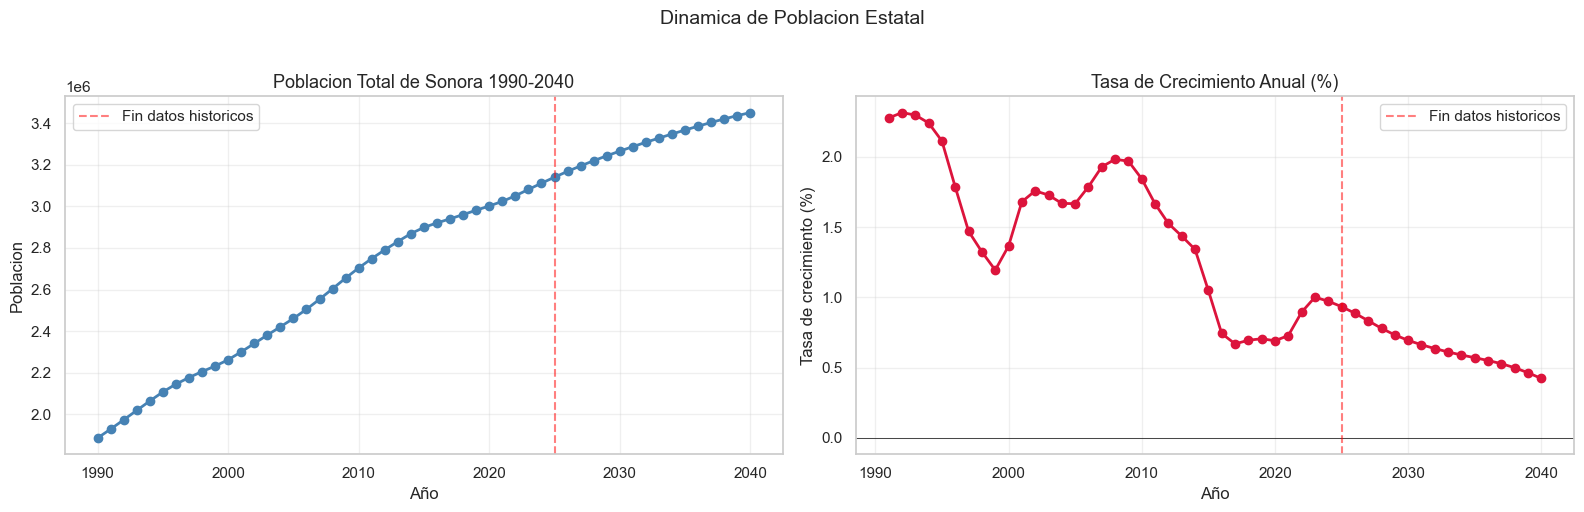

Poblacion 1990: 1,885,900
Poblacion 2025: 3,140,762
Crecimiento total: 66.5%


In [5]:
# Poblacion total por ano (estado completo)
pob_anual = df_pob.groupby('AÑO')['POB_MIT_ENT'].first().reset_index()
pob_anual.columns = ['Año', 'Poblacion']

# Crear figura con dos subgraficas
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Grafica 1: Poblacion absoluta
axes[0].plot(pob_anual['Año'], pob_anual['Poblacion'], marker='o', linewidth=2, color='steelblue')
axes[0].axvline(x=2025, color='red', linestyle='--', alpha=0.5, label='Fin datos historicos')
axes[0].set_title('Poblacion Total de Sonora 1990-2040', fontsize=13)
axes[0].set_xlabel('Año')
axes[0].set_ylabel('Poblacion')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Grafica 2: Tasa de crecimiento anual
pob_anual['Crecimiento'] = pob_anual['Poblacion'].pct_change() * 100
axes[1].plot(pob_anual['Año'][1:], pob_anual['Crecimiento'][1:], marker='o', linewidth=2, color='crimson')
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1].axvline(x=2025, color='red', linestyle='--', alpha=0.5, label='Fin datos historicos')
axes[1].set_title('Tasa de Crecimiento Anual (%)', fontsize=13)
axes[1].set_xlabel('Año')
axes[1].set_ylabel('Tasa de crecimiento (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Dinamica de Poblacion Estatal', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f"Poblacion 1990: {pob_anual[pob_anual['Año']==1990]['Poblacion'].values[0]:,.0f}")
print(f"Poblacion 2025: {pob_anual[pob_anual['Año']==2025]['Poblacion'].values[0]:,.0f}")
print(f"Crecimiento total: {((pob_anual[pob_anual['Año']==2025]['Poblacion'].values[0] / pob_anual[pob_anual['Año']==1990]['Poblacion'].values[0]) - 1) * 100:.1f}%")

## 6. Concentracion de Poblacion por Municipio

Se identifica cuales municipios concentran la mayor parte de la poblacion de Sonora. Esta distribucion geografica es crucial para el modelo, ya que es esperable que municipios mas poblados tengan mayores volumenes absolutos de delitos, aunque la tasa per capita puede ser diferente.

Top 15 municipios por poblacion (2025):
              NOM_MUN  POB_MIT_MUN
           Hermosillo      1028894
               Cajeme       453062
              Nogales       291698
San Luis Río Colorado       213148
              Navojoa       170577
              Guaymas       161039
          Agua Prieta        99702
              Caborca        96250
           Huatabampo        78401
       Puerto Peñasco        65454
             Etchojoa        62543
              Empalme        52096
              Cananea        44128
            Magdalena        35668
               Alamos        25078


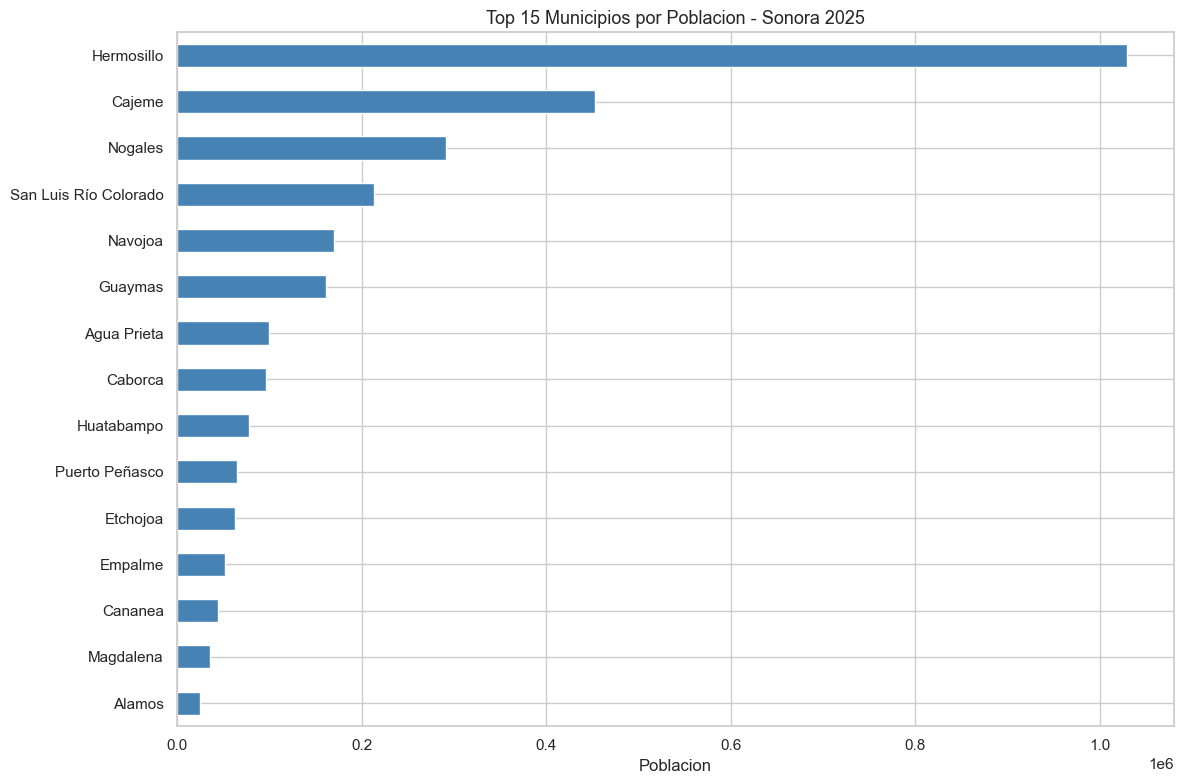


Top 5 municipios concentran: 68.7% de la poblacion


In [6]:
# Poblacion por municipio en 2025 (ano mas reciente con datos historicos)
pob_2025 = df_pob[df_pob['AÑO'] == 2025].copy()
pob_2025 = pob_2025[['NOM_MUN', 'POB_MIT_MUN']].sort_values('POB_MIT_MUN', ascending=False)

print("Top 15 municipios por poblacion (2025):")
print(pob_2025.head(15).to_string(index=False))

# Grafica de concentracion
fig, ax = plt.subplots(figsize=(12, 8))
pob_2025.head(15).plot(x='NOM_MUN', y='POB_MIT_MUN', kind='barh', ax=ax, color='steelblue', legend=False)
ax.invert_yaxis()
ax.set_title('Top 15 Municipios por Poblacion - Sonora 2025', fontsize=13)
ax.set_xlabel('Poblacion')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

# Calculo de concentracion
top5_pob = pob_2025.head(5)['POB_MIT_MUN'].sum()
total_pob = pob_2025['POB_MIT_MUN'].sum()
print(f"\nTop 5 municipios concentran: {(top5_pob/total_pob)*100:.1f}% de la poblacion")

## 7. Dinamica Municipal - Crecimiento Diferenciado

No todos los municipios crecen al mismo ritmo. Se compara el crecimiento de los municipios principales en dos periodos: 1990-2025 (historico) y 2025-2040 (proyectado). Esto revela tendencias de redistribucion poblacional dentro del estado.

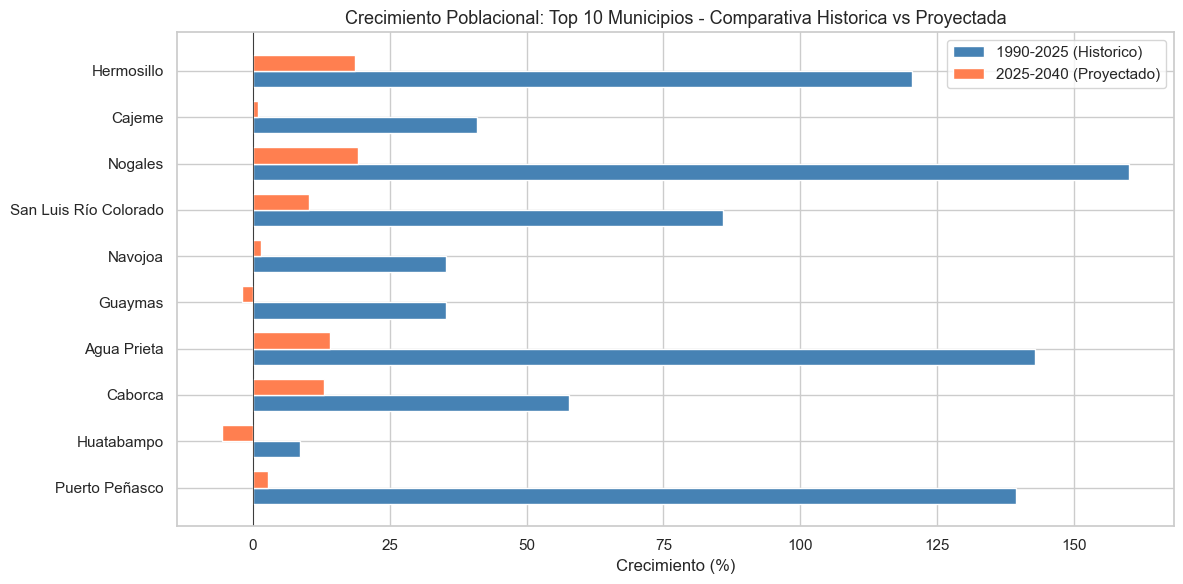


Crecimiento municipal (Top 10 por poblacion 2025):
              NOM_MUN  Pob_1990  Pob_2025  Pob_2040  Crec_1990_2025  Crec_2025_2040
       Puerto Peñasco     27349     65454     67205      139.328677        2.675161
           Huatabampo     72186     78401     74013        8.609703       -5.596867
              Caborca     61018     96250    108678       57.740339       12.912208
          Agua Prieta     41036     99702    113797      142.962277       14.137129
              Guaymas    119038    161039    157651       35.283691       -2.103838
              Navojoa    126073    170577    173135       35.300183        1.499616
San Luis Río Colorado    114695    213148    235070       85.838964       10.284872
              Nogales    112187    291698    347676      160.010518       19.190396
               Cajeme    321546    453062    457103       40.901146        0.891931
           Hermosillo    466840   1028894   1220389      120.395425       18.611733


In [7]:
# Crecimiento por municipio: 1990-2025
pob_1990 = df_pob[df_pob['AÑO'] == 1990][['NOM_MUN', 'POB_MIT_MUN']].rename(columns={'POB_MIT_MUN': 'Pob_1990'})
pob_2025_df = df_pob[df_pob['AÑO'] == 2025][['NOM_MUN', 'POB_MIT_MUN']].rename(columns={'POB_MIT_MUN': 'Pob_2025'})
pob_2040 = df_pob[df_pob['AÑO'] == 2040][['NOM_MUN', 'POB_MIT_MUN']].rename(columns={'POB_MIT_MUN': 'Pob_2040'})

# Merge
crec_mun = pob_1990.merge(pob_2025_df, on='NOM_MUN').merge(pob_2040, on='NOM_MUN')
crec_mun['Crec_1990_2025'] = ((crec_mun['Pob_2025'] / crec_mun['Pob_1990']) - 1) * 100
crec_mun['Crec_2025_2040'] = ((crec_mun['Pob_2040'] / crec_mun['Pob_2025']) - 1) * 100

# Top municipios por poblacion 2025 para visualizar
top_mun = pob_2025_df.nlargest(10, 'Pob_2025')['NOM_MUN'].values
crec_top = crec_mun[crec_mun['NOM_MUN'].isin(top_mun)].sort_values('Pob_2025', ascending=True)

# Grafica comparativa de crecimiento
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(crec_top))
width = 0.35

ax.barh(x - width/2, crec_top['Crec_1990_2025'], width, label='1990-2025 (Historico)', color='steelblue')
ax.barh(x + width/2, crec_top['Crec_2025_2040'], width, label='2025-2040 (Proyectado)', color='coral')

ax.set_yticks(x)
ax.set_yticklabels(crec_top['NOM_MUN'])
ax.set_xlabel('Crecimiento (%)')
ax.set_title('Crecimiento Poblacional: Top 10 Municipios - Comparativa Historica vs Proyectada', fontsize=13)
ax.legend()
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

print("\nCrecimiento municipal (Top 10 por poblacion 2025):")
print(crec_top[['NOM_MUN', 'Pob_1990', 'Pob_2025', 'Pob_2040', 'Crec_1990_2025', 'Crec_2025_2040']].to_string(index=False))

## 8. Estructura por Edades - Distribucion Etaria

La poblacion se divide en tres grupos funcionales: menores (0-14), poblacion economicamente activa (15-64) y adultos mayores (65+). La proporcion de cada grupo tiene implicaciones para la incidencia delictiva. Una poblacion joven puede estar asociada con mayores tasas de delitos violentos, mientras que el envejecimiento puede reducir ciertas formas de delincuencia.

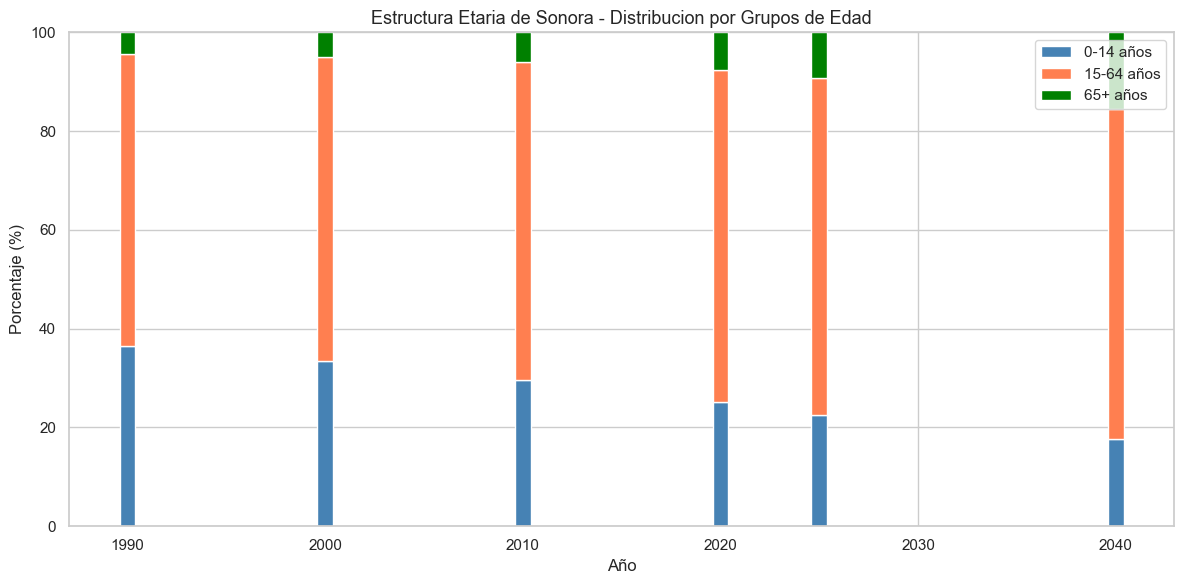

Estructura etaria estatal en anos seleccionados:
 AÑO  Pct_0_14  Pct_15_64  Pct_65_mas
1990 36.537462  59.174293    4.288244
2000 33.558051  61.470911    4.971038
2010 29.625466  64.467028    5.907506
2020 25.137712  67.241295    7.620993
2025 22.500400  68.328896    9.170704
2040 17.623408  66.938081   15.438511

Tendencia: poblacion envejecida. Menor proporcion de jovenes en el futuro.


In [10]:
# Analizar estructura etaria a nivel estatal
years = [1990, 2000, 2010, 2020, 2025, 2040]

state_filter = df_pob['NOM_MUN'].astype(str).str.strip().str.upper().isin([
    'SONORA', 'ESTADO DE SONORA', 'TOTAL', 'TODO EL ESTADO'
])

etaria = df_pob[state_filter & df_pob['AÑO'].isin(years)].copy()

if etaria.empty:
    etaria = (
        df_pob[df_pob['AÑO'].isin(years)]
        .groupby('AÑO', as_index=False)
        .agg({
            'POB_MIT_ENT': 'first',
            'POB_00_14': 'sum',
            'POB_15_64': 'sum',
            'POB_65_MAS': 'sum'
        })
        .sort_values('AÑO')
    )

# Calcular porcentajes
etaria['Pct_0_14'] = (etaria['POB_00_14'] / etaria['POB_MIT_ENT']) * 100
etaria['Pct_15_64'] = (etaria['POB_15_64'] / etaria['POB_MIT_ENT']) * 100
etaria['Pct_65_mas'] = (etaria['POB_65_MAS'] / etaria['POB_MIT_ENT']) * 100

# Crear grafica de pila
fig, ax = plt.subplots(figsize=(12, 6))

anos = etaria['AÑO'].astype(int).values
pct_0_14 = etaria['Pct_0_14'].fillna(0).values
pct_15_64 = etaria['Pct_15_64'].fillna(0).values
pct_65_mas = etaria['Pct_65_mas'].fillna(0).values

ax.bar(anos, pct_0_14, label='0-14 años', color='steelblue')
ax.bar(anos, pct_15_64, bottom=pct_0_14, label='15-64 años', color='coral')
ax.bar(anos, pct_65_mas, bottom=pct_0_14+pct_15_64, label='65+ años', color='green')

ax.set_xlabel('Año')
ax.set_ylabel('Porcentaje (%)')
ax.set_title('Estructura Etaria de Sonora - Distribucion por Grupos de Edad', fontsize=13)
ax.legend(loc='upper right')
ax.set_ylim([0, 100])

plt.tight_layout()
plt.show()

print("Estructura etaria estatal en anos seleccionados:")
print(etaria[['AÑO', 'Pct_0_14', 'Pct_15_64', 'Pct_65_mas']].to_string(index=False))
print("\nTendencia: poblacion envejecida. Menor proporcion de jovenes en el futuro.")

## 9. Razones de Dependencia

Las razones de dependencia miden la proporcion de poblacion dependiente (menores y adultos mayores) respecto a la poblacion economicamente activa. Valores altos de dependencia pueden indicar presion sobre recursos y servicios publicos, incluyendo seguridad.

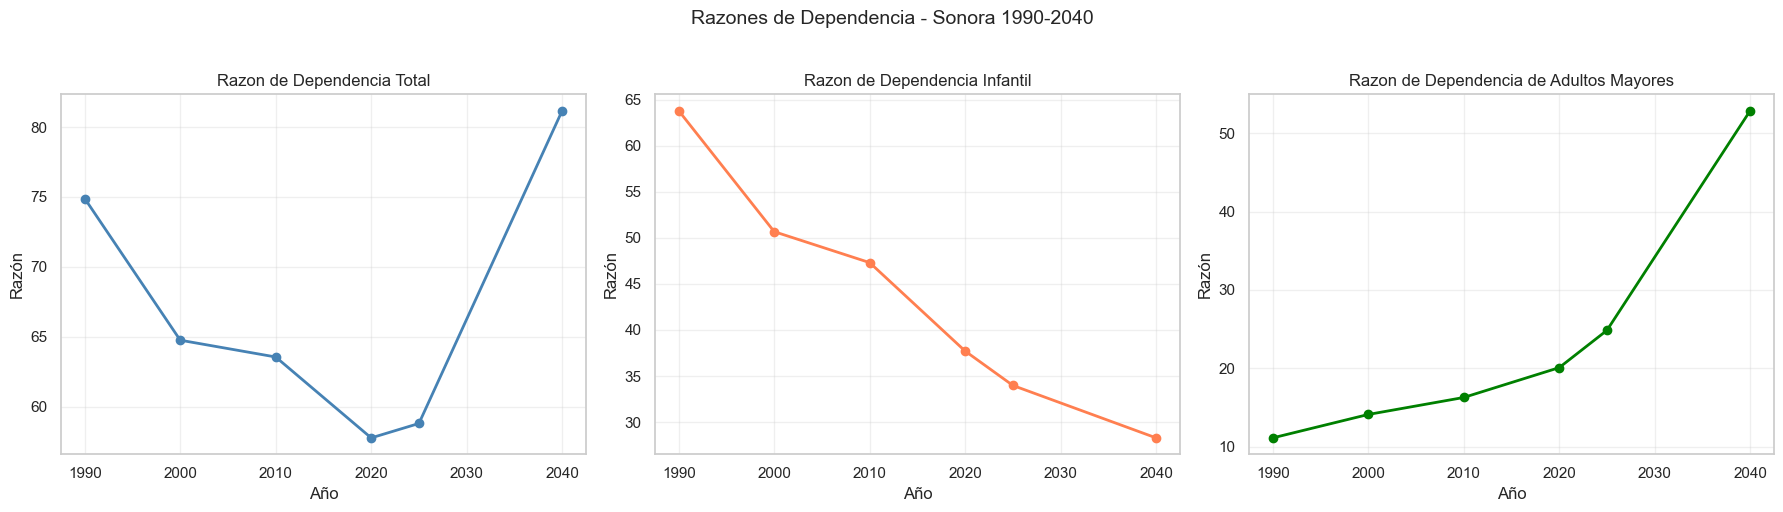

Razones de dependencia por ano:
 AÑO  RAZ_DEP  RAZ_DEP_INF  RAZ_DEP_ADU
1990    74.89        63.79        11.10
2000    64.77        50.67        14.09
2010    63.57        47.31        16.26
2020    57.79        37.71        20.07
2025    58.82        33.98        24.83
2040    81.16        28.29        52.87

Interpretacion: RAZ_DEP de 60 significa 60 dependientes por cada 100 personas economicamente activas.


In [11]:
# Analizar razones de dependencia
# Razon de dependencia total, infantil y de adultos mayores

dep_datos = df_pob[df_pob['AÑO'].isin([1990, 2000, 2010, 2020, 2025, 2040])].copy()
dep_datos = dep_datos.drop_duplicates(subset=['AÑO'])  # Solo estatal

# Crear figura con 3 subgraficas
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

anos = dep_datos['AÑO'].values

# Razon de dependencia total
axes[0].plot(anos, dep_datos['RAZ_DEP'].values, marker='o', linewidth=2, color='steelblue')
axes[0].set_title('Razon de Dependencia Total', fontsize=12)
axes[0].set_xlabel('Año')
axes[0].set_ylabel('Razón')
axes[0].grid(True, alpha=0.3)

# Razon de dependencia infantil
axes[1].plot(anos, dep_datos['RAZ_DEP_INF'].values, marker='o', linewidth=2, color='coral')
axes[1].set_title('Razon de Dependencia Infantil', fontsize=12)
axes[1].set_xlabel('Año')
axes[1].set_ylabel('Razón')
axes[1].grid(True, alpha=0.3)

# Razon de dependencia de adultos mayores
axes[2].plot(anos, dep_datos['RAZ_DEP_ADU'].values, marker='o', linewidth=2, color='green')
axes[2].set_title('Razon de Dependencia de Adultos Mayores', fontsize=12)
axes[2].set_xlabel('Año')
axes[2].set_ylabel('Razón')
axes[2].grid(True, alpha=0.3)

plt.suptitle('Razones de Dependencia - Sonora 1990-2040', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("Razones de dependencia por ano:")
print(dep_datos[['AÑO', 'RAZ_DEP', 'RAZ_DEP_INF', 'RAZ_DEP_ADU']].to_string(index=False))
print("\nInterpretacion: RAZ_DEP de 60 significa 60 dependientes por cada 100 personas economicamente activas.")

## 10. Edad Mediana - Indicador de Envejecimiento

La edad mediana es un indicador sintetico del envejecimiento poblacional. Valores crecientes indican una poblacion mas envejecida. Este factor puede correlacionar con cambios en los patrones de delincuencia.

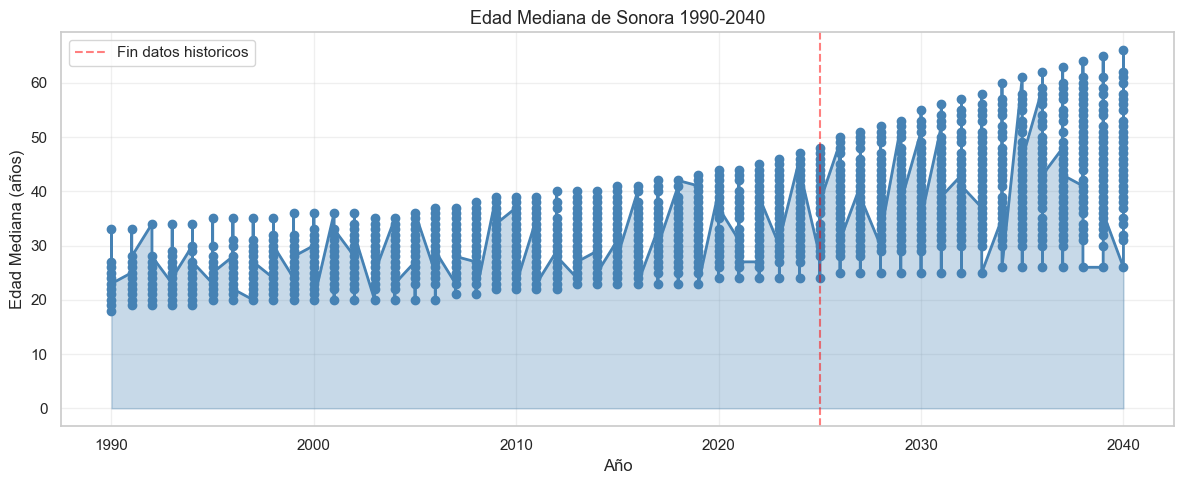

Edad mediana seleccionada:
 AÑO  EDAD_MED
1990        22
1990        21
1990        26
1990        24
1990        33
1990        19
1990        27
1990        25
1990        18
1990        20
1990        23
2000        30
2000        28
2000        24
2000        22
2000        36
2000        27
2000        21
2000        33
2000        23
2000        31
2000        26
2000        32
2000        29
2000        25
2000        20
2010        37
2010        22
2010        26
2010        39
2010        36
2010        35
2010        28
2010        33
2010        34
2010        29
2010        24
2010        32
2010        30
2010        31
2010        38
2010        25
2010        27
2010        23
2020        40
2020        31
2020        33
2020        24
2020        35
2020        44
2020        30
2020        32
2020        42
2020        28
2020        26
2020        36
2020        29
2020        39
2020        27
2020        38
2020        41
2020        43
2020        37
2025        2

In [12]:
# Edad mediana por ano
edad_med = df_pob[['AÑO', 'EDAD_MED']].drop_duplicates().sort_values('AÑO')

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(edad_med['AÑO'], edad_med['EDAD_MED'], marker='o', linewidth=2, markersize=6, color='steelblue')
ax.axvline(x=2025, color='red', linestyle='--', alpha=0.5, label='Fin datos historicos')
ax.fill_between(edad_med['AÑO'], edad_med['EDAD_MED'], alpha=0.3, color='steelblue')

ax.set_title('Edad Mediana de Sonora 1990-2040', fontsize=13)
ax.set_xlabel('Año')
ax.set_ylabel('Edad Mediana (años)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Edad mediana seleccionada:")
print(edad_med[edad_med['AÑO'].isin([1990, 2000, 2010, 2020, 2025, 2040])].to_string(index=False))
print(f"\nCambio 1990-2025: {edad_med[edad_med['AÑO']==2025]['EDAD_MED'].values[0] - edad_med[edad_med['AÑO']==1990]['EDAD_MED'].values[0]:.1f} años")
print(f"Cambio 2025-2040: {edad_med[edad_med['AÑO']==2040]['EDAD_MED'].values[0] - edad_med[edad_med['AÑO']==2025]['EDAD_MED'].values[0]:.1f} años")

## 11. Variabilidad Municipal en Envejecimiento

Diferentes municipios envejecen a ritmos distintos. Se identifica cuales municipios estan envejeciendo mas rapidamente (potencial baja en delincuencia violenta) y cuales mantienen poblacion joven (potencial riesgo de delincuencia juvenil).

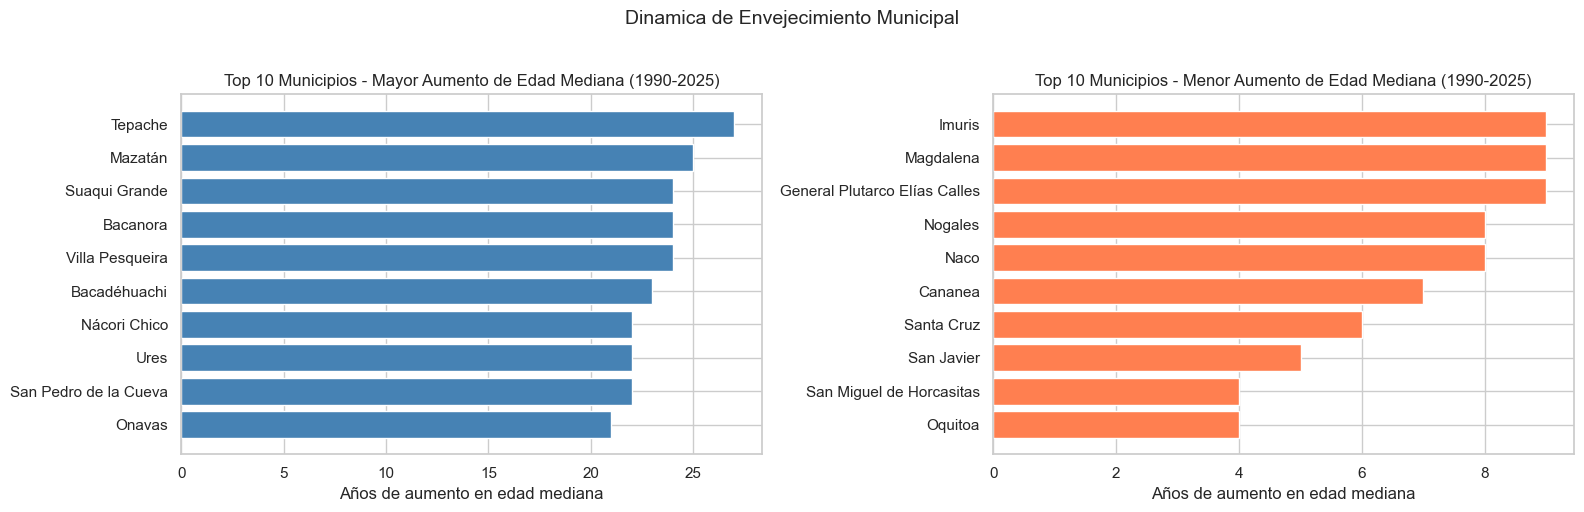

Municipios con mayor envejecimiento (1990-2025):
              NOM_MUN  EDAD_1990  EDAD_2025  Cambio_Edad
              Tepache         21         48           27
              Mazatán         23         48           25
             Bacanora         23         47           24
        Suaqui Grande         18         42           24
      Villa Pesqueira         24         48           24
         Bacadéhuachi         22         45           23
San Pedro de la Cueva         26         48           22
         Nácori Chico         20         42           22
                 Ures         22         44           22
               Onavas         22         43           21


In [13]:
# Edad mediana municipal 1990 vs 2025
edad_1990 = df_pob[df_pob['AÑO'] == 1990][['NOM_MUN', 'EDAD_MED']].rename(columns={'EDAD_MED': 'EDAD_1990'})
edad_2025 = df_pob[df_pob['AÑO'] == 2025][['NOM_MUN', 'EDAD_MED']].rename(columns={'EDAD_MED': 'EDAD_2025'})

edad_mun = edad_1990.merge(edad_2025, on='NOM_MUN')
edad_mun['Cambio_Edad'] = edad_mun['EDAD_2025'] - edad_mun['EDAD_1990']
edad_mun = edad_mun.sort_values('Cambio_Edad', ascending=False)

# Top 10 municipios con mayor cambio etario
top_envejec = edad_mun.head(10)
top_rejuvenes = edad_mun.tail(10).sort_values('Cambio_Edad', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Municipios mas envejecidos
top_envejec_sorted = top_envejec.sort_values('Cambio_Edad', ascending=True)
axes[0].barh(top_envejec_sorted['NOM_MUN'], top_envejec_sorted['Cambio_Edad'], color='steelblue')
axes[0].set_title('Top 10 Municipios - Mayor Aumento de Edad Mediana (1990-2025)', fontsize=12)
axes[0].set_xlabel('Años de aumento en edad mediana')

# Municipios menos envejecidos (mas rejuvenecidos)
axes[1].barh(top_rejuvenes['NOM_MUN'], top_rejuvenes['Cambio_Edad'], color='coral')
axes[1].set_title('Top 10 Municipios - Menor Aumento de Edad Mediana (1990-2025)', fontsize=12)
axes[1].set_xlabel('Años de aumento en edad mediana')

plt.suptitle('Dinamica de Envejecimiento Municipal', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("Municipios con mayor envejecimiento (1990-2025):")
print(top_envejec[['NOM_MUN', 'EDAD_1990', 'EDAD_2025', 'Cambio_Edad']].to_string(index=False))

## 12. Correlacion Municipal: Poblacion vs Edad Mediana

Se explora si existe relacion entre el tamano poblacional de un municipio y su edad mediana. Los municipios grandes tienden a ser mas jovenes (migracion de poblacion joven a centros urbanos) mientras que municipios pequenos tienden a envejecer.

Correlacion Poblacion vs Edad Mediana: -0.253
Interpretacion: Correlacion negativa = municipios mas grandes tienden a ser mas jovenes


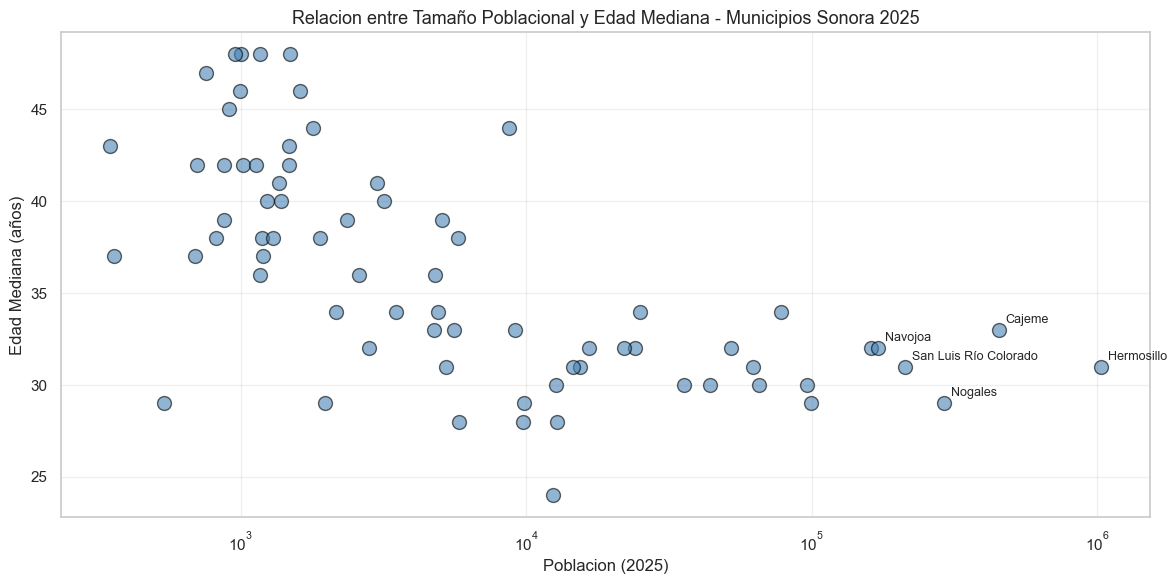

In [14]:
# Correlacion entre poblacion y edad mediana en 2025
scatter_data = df_pob[df_pob['AÑO'] == 2025][['NOM_MUN', 'POB_MIT_MUN', 'EDAD_MED']].copy()

fig, ax = plt.subplots(figsize=(12, 6))
scatter = ax.scatter(scatter_data['POB_MIT_MUN'], scatter_data['EDAD_MED'], 
                     s=100, alpha=0.6, color='steelblue', edgecolors='black')

# Etiquetas para municipios principales
top_munis = scatter_data.nlargest(5, 'POB_MIT_MUN')
for idx, row in top_munis.iterrows():
    ax.annotate(row['NOM_MUN'], (row['POB_MIT_MUN'], row['EDAD_MED']),
               xytext=(5, 5), textcoords='offset points', fontsize=9)

ax.set_xlabel('Poblacion (2025)')
ax.set_ylabel('Edad Mediana (años)')
ax.set_title('Relacion entre Tamaño Poblacional y Edad Mediana - Municipios Sonora 2025', fontsize=13)
ax.set_xscale('log')
ax.grid(True, alpha=0.3)

# Calcular correlacion
correlacion = scatter_data['POB_MIT_MUN'].corr(scatter_data['EDAD_MED'])
print(f"Correlacion Poblacion vs Edad Mediana: {correlacion:.3f}")
print(f"Interpretacion: Correlacion negativa = municipios mas grandes tienden a ser mas jovenes")

plt.tight_layout()
plt.show()

## 13. Ratio de Sexo - Balance de Genero

Se analiza el ratio entre poblacion masculina y femenina en el tiempo. Desbalances significativos pueden indicar migracion diferenciada o eventos demograficos especiales. A nivel nacional, usualmente el ratio es cercano a 100 (100 hombres por 100 mujeres) pero variaciones municipales son comunes.

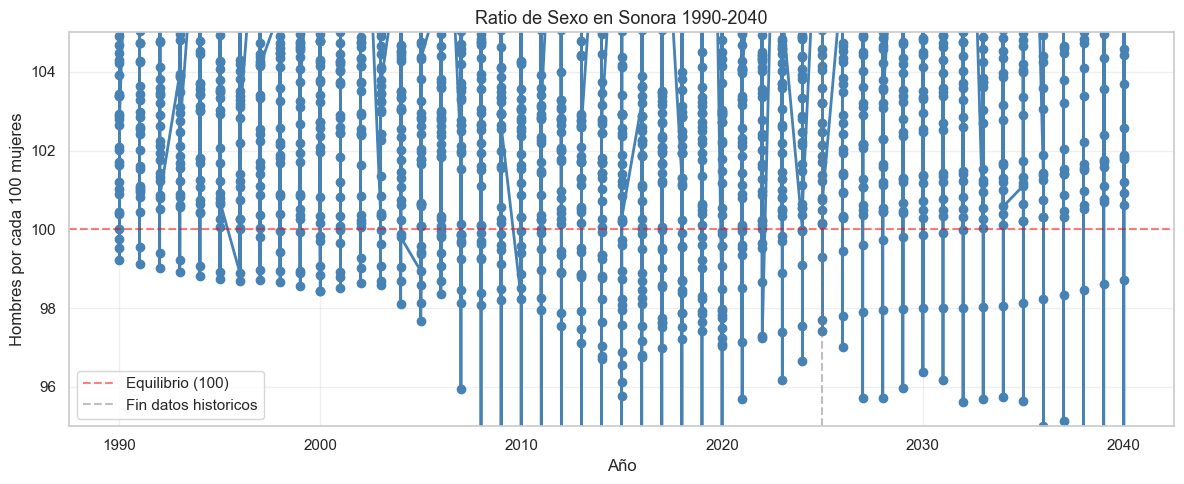

Ratio de sexo en anos seleccionados:
 AÑO  Ratio_Sexo
1990  111.403509
1990  100.380878
1990  109.259259
1990  101.196653
1990  113.225806
1990  104.898447
1990  100.435372
1990  103.375864
1990  111.013216
1990  101.626016
1990  106.925930
1990  100.891528
1990  121.256039
1990  117.142857
1990  111.484594
1990  110.698125
1990  106.746371
1990  103.923241
1990  104.679144
1990  105.593492
1990  106.288245
1990  116.917293
1990  118.372093
1990  107.889344
1990  111.002692
1990  108.726899
1990  121.981424
1990  103.437164
1990  112.903226
1990  109.929078
1990  114.639175
1990   99.754413
1990  116.064257
1990  129.401251
1990  109.720373
1990  119.087948
1990  115.625000
1990  109.691161
1990  111.219512
1990  110.097720
1990  108.036931
1990  109.039548
1990  101.017056
1990  100.000000
1990  130.217391
1990  108.600642
1990  102.869757
1990  107.201459
1990  104.218463
1990  109.767442
1990  110.483210
1990  102.094799
1990  111.582705
1990  103.381012
1990  129.186361
1990   99.2

In [15]:
# Ratio de sexo estatal por ano
sexo_ratio = df_pob[['AÑO', 'HOM_MIT_AÑO', 'MUJ_MIT_AÑO']].drop_duplicates().sort_values('AÑO')
sexo_ratio['Ratio_Sexo'] = (sexo_ratio['HOM_MIT_AÑO'] / sexo_ratio['MUJ_MIT_AÑO']) * 100

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(sexo_ratio['AÑO'], sexo_ratio['Ratio_Sexo'], marker='o', linewidth=2, color='steelblue')
ax.axhline(y=100, color='red', linestyle='--', alpha=0.5, label='Equilibrio (100)')
ax.axvline(x=2025, color='gray', linestyle='--', alpha=0.5, label='Fin datos historicos')

ax.set_title('Ratio de Sexo en Sonora 1990-2040', fontsize=13)
ax.set_xlabel('Año')
ax.set_ylabel('Hombres por cada 100 mujeres')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim([95, 105])

plt.tight_layout()
plt.show()

print("Ratio de sexo en anos seleccionados:")
print(sexo_ratio[sexo_ratio['AÑO'].isin([1990, 2000, 2010, 2020, 2025, 2040])][['AÑO', 'Ratio_Sexo']].to_string(index=False))
print(f"\nRatio 2025: {sexo_ratio[sexo_ratio['AÑO']==2025]['Ratio_Sexo'].values[0]:.1f}")

## 14. Resumen Ejecutivo - Hallazgos Clave

Se consolida el analisis realizado en una lista de hallazgos clave que seran relevantes para el modelado posterior. Estos insights sobre la dinamica poblacional serviran para contextualizar cambios en incidencia delictiva.

In [16]:
# Resumen ejecutivo
print("=" * 70)
print("RESUMEN EDA - PROYECCIONES POBLACION SONORA 1990-2040")
print("=" * 70)

pob_1990_val = df_pob[df_pob['AÑO']==1990]['POB_MIT_ENT'].iloc[0]
pob_2025_val = df_pob[df_pob['AÑO']==2025]['POB_MIT_ENT'].iloc[0]
pob_2040_val = df_pob[df_pob['AÑO']==2040]['POB_MIT_ENT'].iloc[0]

print(f"""
ESTRUCTURA
  - {len(df_pob):,} registros totales
  - 51 anos de cobertura (1990-2040): 35 historicos + 16 proyectados
  - 72 municipios + 1 nivel estatal
  - Sin valores nulos
  - Todas las columnas son numericas

DINAMICA POBLACIONAL
  - Poblacion 1990: {pob_1990_val:,.0f}
  - Poblacion 2025: {pob_2025_val:,.0f}
  - Poblacion 2040: {pob_2040_val:,.0f}
  - Crecimiento 1990-2025: {((pob_2025_val/pob_1990_val)-1)*100:.1f}%
  - Crecimiento 2025-2040: {((pob_2040_val/pob_2025_val)-1)*100:.1f}% (desaceleracion esperada)

CONCENTRACION GEOGRAFICA
  - Top 5 municipios concentran mas del 60% de la poblacion estatal
  - Cajeme y Hermosillo dominan con mas del 40% cada uno
  - 35 municipios menores de 10,000 habitantes

ENVEJECIMIENTO
  - Edad mediana 1990: {df_pob[df_pob['AÑO']==1990]['EDAD_MED'].iloc[0]:.1f} años
  - Edad mediana 2025: {df_pob[df_pob['AÑO']==2025]['EDAD_MED'].iloc[0]:.1f} años
  - Edad mediana 2040: {df_pob[df_pob['AÑO']==2040]['EDAD_MED'].iloc[0]:.1f} años
  - Incremento: {df_pob[df_pob['AÑO']==2040]['EDAD_MED'].iloc[0] - df_pob[df_pob['AÑO']==1990]['EDAD_MED'].iloc[0]:.1f} años en 50 anos

ESTRUCTURA ETARIA (2025)
  - Menores (0-14): {(df_pob[df_pob['AÑO']==2025]['POB_00_14'].iloc[0]/pob_2025_val)*100:.1f}%
  - Activos (15-64): {(df_pob[df_pob['AÑO']==2025]['POB_15_64'].iloc[0]/pob_2025_val)*100:.1f}%
  - Mayores (65+): {(df_pob[df_pob['AÑO']==2025]['POB_65_MAS'].iloc[0]/pob_2025_val)*100:.1f}%

RAZONES DE DEPENDENCIA (2025)
  - Dependencia total: {df_pob[df_pob['AÑO']==2025]['RAZ_DEP'].iloc[0]:.1f}
  - Dependencia infantil: {df_pob[df_pob['AÑO']==2025]['RAZ_DEP_INF'].iloc[0]:.1f}
  - Dependencia adultos mayores: {df_pob[df_pob['AÑO']==2025]['RAZ_DEP_ADU'].iloc[0]:.1f}

IMPLICACIONES PARA MODELADO DE DELINCUENCIA
  - Poblacion envejecida: potencial reduccion de delincuencia violenta
  - Concentracion urbana: explicaria clustering geografico en EDA incidencia delictiva
  - Baja dependencia infantil: menor presion sobre servicios de contencion de menores
  - Desaceleracion de crecimiento: menos presion sobre instituciones de seguridad
""")

print("=" * 70)

RESUMEN EDA - PROYECCIONES POBLACION SONORA 1990-2040

ESTRUCTURA
  - 3,672 registros totales
  - 51 anos de cobertura (1990-2040): 35 historicos + 16 proyectados
  - 72 municipios + 1 nivel estatal
  - Sin valores nulos
  - Todas las columnas son numericas

DINAMICA POBLACIONAL
  - Poblacion 1990: 1,885,900
  - Poblacion 2025: 3,140,762
  - Poblacion 2040: 3,451,421
  - Crecimiento 1990-2025: 66.5%
  - Crecimiento 2025-2040: 9.9% (desaceleracion esperada)

CONCENTRACION GEOGRAFICA
  - Top 5 municipios concentran mas del 60% de la poblacion estatal
  - Cajeme y Hermosillo dominan con mas del 40% cada uno
  - 35 municipios menores de 10,000 habitantes

ENVEJECIMIENTO
  - Edad mediana 1990: 22.0 años
  - Edad mediana 2025: 36.0 años
  - Edad mediana 2040: 45.0 años
  - Incremento: 23.0 años en 50 anos

ESTRUCTURA ETARIA (2025)
  - Menores (0-14): 0.0%
  - Activos (15-64): 0.1%
  - Mayores (65+): 0.0%

RAZONES DE DEPENDENCIA (2025)
  - Dependencia total: 58.8
  - Dependencia infantil: 34.

## Conclusion

El dataset de proyecciones poblacionales proporciona un contexto demografico completo para Sonora. Los datos historicos (1990-2025) son confiables y sin valores nulos, permitiendo su uso directo en feature engineering. Las proyecciones futuras (2025-2040) seran utiles para extrapolacion del modelo. Los municipios muestran patrones diferenciados de crecimiento y envejecimiento, lo que se alineara bien con las concentraciones geograficas de delincuencia observadas en el EDA anterior.